# DALEX Explainer — OHL Matchday Attendance Models

Model-agnostic explanations for all 4 regression models using the `dalex` library.

| Section | What you get |
|---|---|
| 3. Model Performance | Train vs test error side-by-side |
| 4. Variable Importance | Permutation-based feature rankings |
| 5. PDP Profiles | How features shift the predicted attendance |
| 6. Break Down | Per-match waterfall explanations |
| 7. SHAP Values | Shapley attribution for tree-based models |

## 1. Imports

In [33]:
import dalex as dx
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option('display.max_columns', None)
print('dalex', dx.__version__)

dalex 1.8.0


## 2. Data & Model Setup

In [34]:
FEATURES_NUM = [
    'kickoff_hour', 'is_playoff', 'is_weekend',
    'is_school_holiday_flanders', 'has_promotion',
    'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count',
    'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl',
    'rolling_avg_attendance_last3', 'matchday_normalized',
    'last_h2h_goal_margin', 'ohl_points_per_game',
    'has_campaign', 'pre_match_interest_ratio',
]
FEATURES_CAT = ['opponent_grouped', 'last_h2h_result']
TARGET = 'tickets_scanned'

In [35]:
df = pd.read_csv('../data/cleaned/engineered_df.csv')
model_df = df.copy()

# Derived features
model_df['kickoff_hour'] = pd.to_datetime(
    model_df['kickoff_time_local'], format='%H:%M:%S'
).dt.hour
model_df['is_playoff'] = (model_df['stage'] == 'Conference League Play-off Group').astype(int)

# Fill nulls
model_df['last_h2h_result'] = model_df['last_h2h_result'].fillna('Unknown')
model_df['home_win_rate_last3'] = model_df['home_win_rate_last3'].fillna(0)
model_df['pre_match_article_count'] = model_df['pre_match_article_count'].fillna(
    model_df['pre_match_article_count'].median()
)
model_df['rolling_avg_attendance_last3'] = model_df['rolling_avg_attendance_last3'].fillna(
    model_df['rolling_avg_attendance_last3'].median()
)

# One-hot encode categoricals
encoded = pd.get_dummies(model_df[FEATURES_CAT], drop_first=True)
X = pd.concat([
    model_df[FEATURES_NUM].reset_index(drop=True),
    encoded.reset_index(drop=True)
], axis=1).astype(float)
y = model_df[TARGET].astype(float)

# Season-based train/test split
train_mask = model_df['season'].isin(['2022/2023', '2023/2024', '2024/2025'])
test_mask  = model_df['season'].isin(['2025/2026'])

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')

Train: (57, 36)  |  Test: (14, 36)
Features: ['kickoff_hour', 'is_playoff', 'is_weekend', 'is_school_holiday_flanders', 'has_promotion', 'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count', 'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl', 'rolling_avg_attendance_last3', 'matchday_normalized', 'last_h2h_goal_margin', 'ohl_points_per_game', 'has_campaign', 'pre_match_interest_ratio', 'opponent_grouped_Antwerp', 'opponent_grouped_Cercle Brugge', 'opponent_grouped_Club Brugge', 'opponent_grouped_Dender', 'opponent_grouped_Eupen', 'opponent_grouped_Genk', 'opponent_grouped_Gent', 'opponent_grouped_Kortrijk', 'opponent_grouped_Mechelen', 'opponent_grouped_Other', 'opponent_grouped_Sint-Truiden', 'opponent_grouped_Sporting Charleroi', 'opponent_grouped_Standard Liège', 'opponent_grouped_Union Saint-Gilloise', 'opponent_grouped_Westerlo', 'opponent_grouped_Zulte Waregem', 'last_h2h_result_L', 'last_h2h_result_Unknown', 'last_h2h_result_W']


In [36]:
# Re-train all 4 models with identical hyperparameters as the training notebooks
ols = LinearRegression().fit(X_train, y_train)

ridge = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
).fit(X_train, y_train)

rf = RandomForestRegressor(
    n_estimators=300, max_features='sqrt', min_samples_leaf=3,
    random_state=42, n_jobs=-1
).fit(X_train, y_train)

gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, min_samples_leaf=3, random_state=42
).fit(X_train, y_train)

print('All 4 models trained.')
print(f'Ridge best alpha: {ridge.alpha_}')

All 4 models trained.
Ridge best alpha: 1000.0


## 3. DALEX Explainers

Two sets of explainers:
- **Train explainers** — used for variable importance, PDP profiles, and local explanations (background distribution = training data).
- **Test explainers** — used only for the test-set model performance comparison.

In [37]:
# Training-set explainers
exp_ols   = dx.Explainer(ols,   X_train, y_train, label='OLS',               verbose=False)
exp_ridge = dx.Explainer(ridge, X_train, y_train, label='Ridge',             verbose=False)
exp_rf    = dx.Explainer(rf,    X_train, y_train, label='Random Forest',     verbose=False)
exp_gb    = dx.Explainer(gb,    X_train, y_train, label='Gradient Boosting', verbose=False)

# Test-set explainers (for performance comparison only)
exp_ols_t   = dx.Explainer(ols,   X_test, y_test, label='OLS (test)',               verbose=False)
exp_ridge_t = dx.Explainer(ridge, X_test, y_test, label='Ridge (test)',             verbose=False)
exp_rf_t    = dx.Explainer(rf,    X_test, y_test, label='Random Forest (test)',     verbose=False)
exp_gb_t    = dx.Explainer(gb,    X_test, y_test, label='Gradient Boosting (test)', verbose=False)

print('Explainers ready.')

Explainers ready.


## 4. Model Performance

Comparing RMSE, MAE, and R² on training and test sets.

In [38]:
# Training performance
mp_ols   = exp_ols.model_performance()
mp_ridge = exp_ridge.model_performance()
mp_rf    = exp_rf.model_performance()
mp_gb    = exp_gb.model_performance()

# Tabular summary
perf_train = pd.concat([mp_ols.result, mp_ridge.result, mp_rf.result, mp_gb.result])
print('=== Training Performance ===')
display(perf_train)

mp_ols.plot(
    objects=[mp_ridge, mp_rf, mp_gb],
    title='Model Performance — Training Set'
)

=== Training Performance ===


,mse,rmse,r2,mae,mad
OLS,7.517820e+05,867.053619,0.824269,685.198184,575.167274
Ridge,2.631046e+06,1622.049988,0.384985,1305.537985,920.457575
Random Forest,1.213352e+06,1101.522796,0.716375,889.133166,727.079108
Gradient Boosting,8.695131e+02,29.487507,0.999797,23.902440,19.832848


In [39]:
# Test performance
mp_ols_t   = exp_ols_t.model_performance()
mp_ridge_t = exp_ridge_t.model_performance()
mp_rf_t    = exp_rf_t.model_performance()
mp_gb_t    = exp_gb_t.model_performance()

perf_test = pd.concat([mp_ols_t.result, mp_ridge_t.result, mp_rf_t.result, mp_gb_t.result])
print('=== Test Performance (2025/26 season) ===')
display(perf_test)

mp_ols_t.plot(
    objects=[mp_ridge_t, mp_rf_t, mp_gb_t],
    title='Model Performance — Test Set (2025/26)'
)

=== Test Performance (2025/26 season) ===


,mse,rmse,r2,mae,mad
OLS (test),2.070308e+07,4550.063893,-17.822754,3554.538989,2591.828169
Ridge (test),1.620712e+06,1273.072070,-0.473514,1021.816396,847.620752
Random Forest (test),3.312557e+06,1820.043207,-2.011699,1591.924927,1334.147834
Gradient Boosting (test),2.782811e+06,1668.176076,-1.530067,1477.579412,1572.550189


## 5. Variable Importance (Global)

Permutation-based importance: how much does RMSE increase when a feature's values are randomly shuffled?
Higher dropout loss = more important feature.

In [40]:
vi_ols   = exp_ols.model_parts()
vi_ridge = exp_ridge.model_parts()
vi_rf    = exp_rf.model_parts()
vi_gb    = exp_gb.model_parts()

vi_ols.plot(
    objects=[vi_ridge, vi_rf, vi_gb],
    max_vars=15,
    title='Variable Importance — All 4 Models (top 15 features)'
)

## 6. Partial Dependence Profiles (Global)

How does the **average** predicted attendance change as each feature varies, holding everything else fixed?

In [41]:
# Five most interpretable continuous features
KEY_VARS = [
    'rolling_avg_attendance_last3',
    'ohl_season_points',
    'matchday_normalized',
    'pre_match_interest_ratio',
    'weather_score',
]

pdp_ols   = exp_ols.model_profile(variables=KEY_VARS)
pdp_ridge = exp_ridge.model_profile(variables=KEY_VARS)
pdp_rf    = exp_rf.model_profile(variables=KEY_VARS)
pdp_gb    = exp_gb.model_profile(variables=KEY_VARS)

pdp_ols.plot(
    objects=[pdp_ridge, pdp_rf, pdp_gb],
    title='Partial Dependence Profiles — Key Features'
)

Calculating ceteris paribus: 100%|██████████| 5/5 [00:00<00:00, 75.79it/s]


## 7. Individual Prediction Break Down (Local)

Waterfall decomposition for specific matches:
how much does each feature push the prediction above or below the average?

We pick the **best predicted** match (lowest RF error) and the **worst predicted** match (highest RF error) from the test set.

In [42]:
errors = np.abs(rf.predict(X_test) - y_test.values)
best_idx  = int(np.argmin(errors))
worst_idx = int(np.argmax(errors))

print(f'Best predicted  — index {best_idx}: '
      f'actual={y_test.iloc[best_idx]:.0f}, '
      f'RF pred={rf.predict(X_test.iloc[[best_idx]])[0]:.0f}, '
      f'error={errors[best_idx]:.0f}')
print(f'Worst predicted — index {worst_idx}: '
      f'actual={y_test.iloc[worst_idx]:.0f}, '
      f'RF pred={rf.predict(X_test.iloc[[worst_idx]])[0]:.0f}, '
      f'error={errors[worst_idx]:.0f}')

Best predicted  — index 5: actual=7992, RF pred=7748, error=244
Worst predicted — index 3: actual=4036, RF pred=7216, error=3180


In [43]:
# Break Down — best predicted match
obs_best = X_test.iloc[[best_idx]]

bd_ols_best   = exp_ols.predict_parts(obs_best,   type='break_down')
bd_ridge_best = exp_ridge.predict_parts(obs_best, type='break_down')
bd_rf_best    = exp_rf.predict_parts(obs_best,    type='break_down')
bd_gb_best    = exp_gb.predict_parts(obs_best,    type='break_down')

bd_ols_best.plot(
    objects=[bd_ridge_best, bd_rf_best, bd_gb_best],
    title=f'Break Down — Best Predicted Match (test index {best_idx})'
)

In [44]:
# Break Down — worst predicted match
obs_worst = X_test.iloc[[worst_idx]]

bd_ols_worst   = exp_ols.predict_parts(obs_worst,   type='break_down')
bd_ridge_worst = exp_ridge.predict_parts(obs_worst, type='break_down')
bd_rf_worst    = exp_rf.predict_parts(obs_worst,    type='break_down')
bd_gb_worst    = exp_gb.predict_parts(obs_worst,    type='break_down')

bd_ols_worst.plot(
    objects=[bd_ridge_worst, bd_rf_worst, bd_gb_worst],
    title=f'Break Down — Worst Predicted Match (test index {worst_idx})'
)

## 8. SHAP Values (Local)

Model-agnostic Shapley value estimates for the two tree-based models (RF and GB).
Each bar shows the average contribution of a feature across random orderings (`B=25` Monte Carlo samples).

In [45]:
# SHAP — best predicted match
shap_rf_best = exp_rf.predict_parts(obs_best, type='shap', B=25)
shap_gb_best = exp_gb.predict_parts(obs_best, type='shap', B=25)

shap_rf_best.plot(
    objects=[shap_gb_best],
    title=f'SHAP — Best Predicted Match (test index {best_idx})'
)

In [46]:
# SHAP — worst predicted match
shap_rf_worst = exp_rf.predict_parts(obs_worst, type='shap', B=25)
shap_gb_worst = exp_gb.predict_parts(obs_worst, type='shap', B=25)

shap_rf_worst.plot(
    objects=[shap_gb_worst],
    title=f'SHAP — Worst Predicted Match (test index {worst_idx})'
)

## 9. Alternative Test Split — Test on 2024/25

Re-run with **train: 2022/23 + 2023/24 → test: 2024/25** to check whether the poor test performance in section 4 was caused by the attendance drop specific to 2025/26, or reflects a genuine inability to generalize across seasons.

> Note: the models here are retrained on fewer samples (~38 vs 57), so a direct metric comparison is not apples-to-apples — the diagnostic value is in whether R² flips from negative to positive.

In [47]:
# Re-split: train 2022/23 + 2023/24, test 2024/25
train_mask2 = model_df['season'].isin(['2022/2023', '2023/2024'])
test_mask2  = model_df['season'].isin(['2024/2025'])

X_train2 = X[train_mask2].reset_index(drop=True)
X_test2  = X[test_mask2].reset_index(drop=True)
y_train2 = y[train_mask2].reset_index(drop=True)
y_test2  = y[test_mask2].reset_index(drop=True)

print(f'Alt train: {X_train2.shape}  |  Alt test: {X_test2.shape}')

# Re-train all 4 models on the reduced training set
ols2   = LinearRegression().fit(X_train2, y_train2)
ridge2 = RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]).fit(X_train2, y_train2)
rf2    = RandomForestRegressor(
    n_estimators=300, max_features='sqrt', min_samples_leaf=3,
    random_state=42, n_jobs=-1
).fit(X_train2, y_train2)
gb2    = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, min_samples_leaf=3, random_state=42
).fit(X_train2, y_train2)

# Test explainers for the new split
exp_ols_t2   = dx.Explainer(ols2,   X_test2, y_test2, label='OLS (test 24/25)',               verbose=False)
exp_ridge_t2 = dx.Explainer(ridge2, X_test2, y_test2, label='Ridge (test 24/25)',             verbose=False)
exp_rf_t2    = dx.Explainer(rf2,    X_test2, y_test2, label='RF (test 24/25)',                verbose=False)
exp_gb_t2    = dx.Explainer(gb2,    X_test2, y_test2, label='GB (test 24/25)',                verbose=False)

mp_ols_t2   = exp_ols_t2.model_performance()
mp_ridge_t2 = exp_ridge_t2.model_performance()
mp_rf_t2    = exp_rf_t2.model_performance()
mp_gb_t2    = exp_gb_t2.model_performance()

mp_ols_t2.plot(
    objects=[mp_ridge_t2, mp_rf_t2, mp_gb_t2],
    title='Model Performance — Alt Test Set (2024/25)'
)

Alt train: (37, 36)  |  Alt test: (20, 36)


In [48]:
# Side-by-side: original split (test 2025/26) vs alternative split (test 2024/25)
comparison = pd.DataFrame({
    'R²  — test 2025/26': [
        mp_ols_t.result['r2'].values[0],
        mp_ridge_t.result['r2'].values[0],
        mp_rf_t.result['r2'].values[0],
        mp_gb_t.result['r2'].values[0],
    ],
    'R²  — test 2024/25': [
        mp_ols_t2.result['r2'].values[0],
        mp_ridge_t2.result['r2'].values[0],
        mp_rf_t2.result['r2'].values[0],
        mp_gb_t2.result['r2'].values[0],
    ],
    'RMSE — test 2025/26': [
        mp_ols_t.result['rmse'].values[0],
        mp_ridge_t.result['rmse'].values[0],
        mp_rf_t.result['rmse'].values[0],
        mp_gb_t.result['rmse'].values[0],
    ],
    'RMSE — test 2024/25': [
        mp_ols_t2.result['rmse'].values[0],
        mp_ridge_t2.result['rmse'].values[0],
        mp_rf_t2.result['rmse'].values[0],
        mp_gb_t2.result['rmse'].values[0],
    ],
}, index=['OLS', 'Ridge', 'Random Forest', 'Gradient Boosting'])

display(comparison.round(3))

,R² — test 2025/26,R² — test 2024/25,RMSE — test 2025/26,RMSE — test 2024/25
OLS,-17.823,-8.474,4550.064,5366.694
Ridge,-0.474,0.055,1273.072,1694.517
Random Forest,-2.012,0.068,1820.043,1683.359
Gradient Boosting,-1.530,-0.246,1668.176,1946.499


## 10. Reduced Feature Set + Small-Data Models

The core problem is a **feature/sample ratio of 36:57 ≈ 1:1.6** — far too high for reliable generalisation.

**Strategy:**
- Drop all one-hot dummies; replace categoricals with numeric proxies (`opp_ppg_vs_ohl` instead of 14 opponent dummies, `last_h2h_goal_margin` instead of 3 h2h result dummies)
- Add two previously unused numeric features: `weather_temp_deviation` and `academic_week`
- Result: **14 numeric features** → ratio improves to ~4:1
- Use models with stronger built-in regularisation suited to small datasets: Bayesian Ridge, ElasticNet, SVR (RBF kernel)
- All models wrapped in a `StandardScaler` pipeline since L1/L2 penalties and RBF distances are scale-sensitive

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge, ElasticNetCV

from sklearn.svm import SVR

FEATURES_REDUCED = [
    # Attendance momentum
    'rolling_avg_attendance_last3',
    # Team form (rate-based; drops correlated ohl_season_points)
    'ohl_points_per_game',
    'home_win_rate_last3',
    # Schedule & calendar
    'matchday_normalized',
    'is_weekend',
    'is_school_holiday_flanders',
    'academic_week',           # NEW: continuous week-of-year (1–52)
    # Marketing
    'has_promotion',
    # Weather
    'weather_score',
    'weather_temp_deviation',  # NEW: °C deviation from seasonal norm
    # Fan interest
    'avg_ohl_interest_7d',
    'pre_match_interest_ratio',
    # Opponent & h2h (numeric proxies — no dummies)
    'opp_ppg_vs_ohl',          # replaces 14 opponent dummies
    'last_h2h_goal_margin',    # replaces 3 last_h2h_result dummies
]

print(f'{len(FEATURES_REDUCED)} features (was 36)')

14 features (was 36)


In [50]:
# Build reduced feature matrix — no get_dummies needed (all numeric)
# model_df already has nulls filled from the preprocessing cell above
X_red = model_df[FEATURES_REDUCED].copy().astype(float)
y_red = model_df[TARGET].astype(float)

X_red_train = X_red[train_mask].reset_index(drop=True)
X_red_test  = X_red[test_mask].reset_index(drop=True)
y_red_train = y_red[train_mask].reset_index(drop=True)
y_red_test  = y_red[test_mask].reset_index(drop=True)

print(f'Reduced train: {X_red_train.shape}  |  Reduced test: {X_red_test.shape}')

# --- Train 4 models (all scaled via Pipeline) ---
ridge_red = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000])),
]).fit(X_red_train, y_red_train)

bayesian = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  BayesianRidge()),
]).fit(X_red_train, y_red_train)

elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  ElasticNetCV(cv=5, l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0], max_iter=10000)),
]).fit(X_red_train, y_red_train)

svr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVR(kernel='rbf', C=1000, epsilon=100)),
]).fit(X_red_train, y_red_train)

print('Models trained.')
print(f"Ridge alpha:       {ridge_red.named_steps['model'].alpha_:.3f}")
print(f"ElasticNet alpha:  {elastic.named_steps['model'].alpha_:.4f}  "
      f"l1_ratio: {elastic.named_steps['model'].l1_ratio_:.2f}")

Reduced train: (57, 14)  |  Reduced test: (14, 14)
Models trained.
Ridge alpha:       50.000
ElasticNet alpha:  138.7332  l1_ratio: 1.00


In [51]:
# DALEX explainers — train set
exp_ridge_red = dx.Explainer(ridge_red, X_red_train, y_red_train, label='Ridge (reduced)',    verbose=False)
exp_bayesian  = dx.Explainer(bayesian,  X_red_train, y_red_train, label='Bayesian Ridge',     verbose=False)
exp_elastic   = dx.Explainer(elastic,   X_red_train, y_red_train, label='ElasticNet',         verbose=False)
exp_svr       = dx.Explainer(svr,       X_red_train, y_red_train, label='SVR (RBF)',          verbose=False)

# DALEX explainers — test set
exp_ridge_red_t = dx.Explainer(ridge_red, X_red_test, y_red_test, label='Ridge (reduced) test', verbose=False)
exp_bayesian_t  = dx.Explainer(bayesian,  X_red_test, y_red_test, label='Bayesian Ridge test',  verbose=False)
exp_elastic_t   = dx.Explainer(elastic,   X_red_test, y_red_test, label='ElasticNet test',      verbose=False)
exp_svr_t       = dx.Explainer(svr,       X_red_test, y_red_test, label='SVR (RBF) test',       verbose=False)

# Performance on test set
mp_ridge_red_t = exp_ridge_red_t.model_performance()
mp_bayesian_t  = exp_bayesian_t.model_performance()
mp_elastic_t   = exp_elastic_t.model_performance()
mp_svr_t       = exp_svr_t.model_performance()

perf_red = pd.concat([
    mp_ridge_red_t.result,
    mp_bayesian_t.result,
    mp_elastic_t.result,
    mp_svr_t.result,
])
print('=== Reduced-feature Test Performance (2025/26) ===')
display(perf_red)

mp_ridge_red_t.plot(
    objects=[mp_bayesian_t, mp_elastic_t, mp_svr_t],
    title='Model Performance — Reduced Features, Test Set (2025/26)'
)

=== Reduced-feature Test Performance (2025/26) ===


,mse,rmse,r2,mae,mad
Ridge (reduced) test,2.326112e+06,1525.159588,-1.114846,1303.803747,1215.972224
Bayesian Ridge test,2.110196e+06,1452.651431,-0.918541,1232.222902,1074.334249
ElasticNet test,1.733259e+06,1316.532797,-0.575838,1069.363338,953.438893
SVR (RBF) test,2.081764e+06,1442.831815,-0.892690,1220.077788,959.166369


In [52]:
# Variable importance for the reduced-feature models
vi_ridge_red = exp_ridge_red.model_parts()
vi_bayesian  = exp_bayesian.model_parts()
vi_elastic   = exp_elastic.model_parts()
vi_svr       = exp_svr.model_parts()

vi_ridge_red.plot(
    objects=[vi_bayesian, vi_elastic, vi_svr],
    max_vars=14,
    title='Variable Importance — Reduced Features, All 4 Models'
)

In [53]:
# Final comparison: new reduced-feature models vs original Ridge (36 features)
# on the same test set (2025/26)
comparison_final = pd.DataFrame({
    'R²  — test 2025/26': [
        mp_ridge_t.result['r2'].values[0],       # original Ridge (36 features)
        mp_ridge_red_t.result['r2'].values[0],   # Ridge (14 features)
        mp_bayesian_t.result['r2'].values[0],
        mp_elastic_t.result['r2'].values[0],
        mp_svr_t.result['r2'].values[0],
    ],
    'RMSE — test 2025/26': [
        mp_ridge_t.result['rmse'].values[0],
        mp_ridge_red_t.result['rmse'].values[0],
        mp_bayesian_t.result['rmse'].values[0],
        mp_elastic_t.result['rmse'].values[0],
        mp_svr_t.result['rmse'].values[0],
    ],
    'MAE — test 2025/26': [
        mp_ridge_t.result['mae'].values[0],
        mp_ridge_red_t.result['mae'].values[0],
        mp_bayesian_t.result['mae'].values[0],
        mp_elastic_t.result['mae'].values[0],
        mp_svr_t.result['mae'].values[0],
    ],
}, index=['Ridge (36 features)', 'Ridge (14 features)', 'Bayesian Ridge', 'ElasticNet', 'SVR (RBF)'])

display(comparison_final.round(3))

,R² — test 2025/26,RMSE — test 2025/26,MAE — test 2025/26
Ridge (36 features),-0.474,1273.072,1021.816
Ridge (14 features),-1.115,1525.160,1303.804
Bayesian Ridge,-0.919,1452.651,1232.223
ElasticNet,-0.576,1316.533,1069.363
SVR (RBF),-0.893,1442.832,1220.078


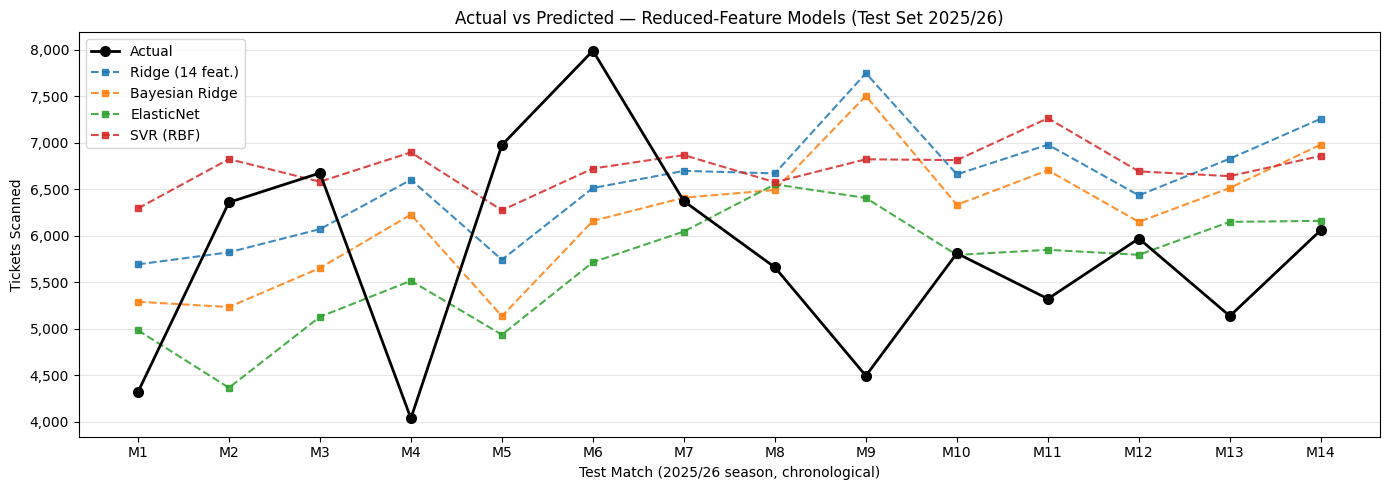

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

preds_red = {
    'Ridge (14 feat.)': ridge_red.predict(X_red_test),
    'Bayesian Ridge':   bayesian.predict(X_red_test),
    'ElasticNet':       elastic.predict(X_red_test),
    'SVR (RBF)':        svr.predict(X_red_test),
}

x = np.arange(len(y_red_test))
match_labels = [f'M{i+1}' for i in range(len(y_red_test))]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Plot 1: Actual vs predicted per match (line/dot) ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, y_red_test.values, 'o-', color='black', linewidth=2,
        markersize=7, label='Actual', zorder=5)
for (label, pred), color in zip(preds_red.items(), colors):
    ax.plot(x, pred, 's--', color=color, linewidth=1.5,
            markersize=5, label=label, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(match_labels)
ax.set_xlabel('Test Match (2025/26 season, chronological)')
ax.set_ylabel('Tickets Scanned')
ax.set_title('Actual vs Predicted — Reduced-Feature Models (Test Set 2025/26)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## 11. ElasticNet with Underestimation Bias

Post-hoc bias correction on ElasticNet predictions:
1. Measure how much ElasticNet systematically overestimates on the **training set** (mean residual)
2. Subtract that + a fixed safety buffer to push predictions conservatively below actual

Training residuals (predicted − actual):
  Mean (systematic overestimation): +0 tickets
  Std:                              1479 tickets

Correction applied: 800 tickets
  = mean bias (0) + safety buffer (800)

                                   Original   Conservative
MAE (test)                             1069           1228
% matches overestimated                 50%            29%


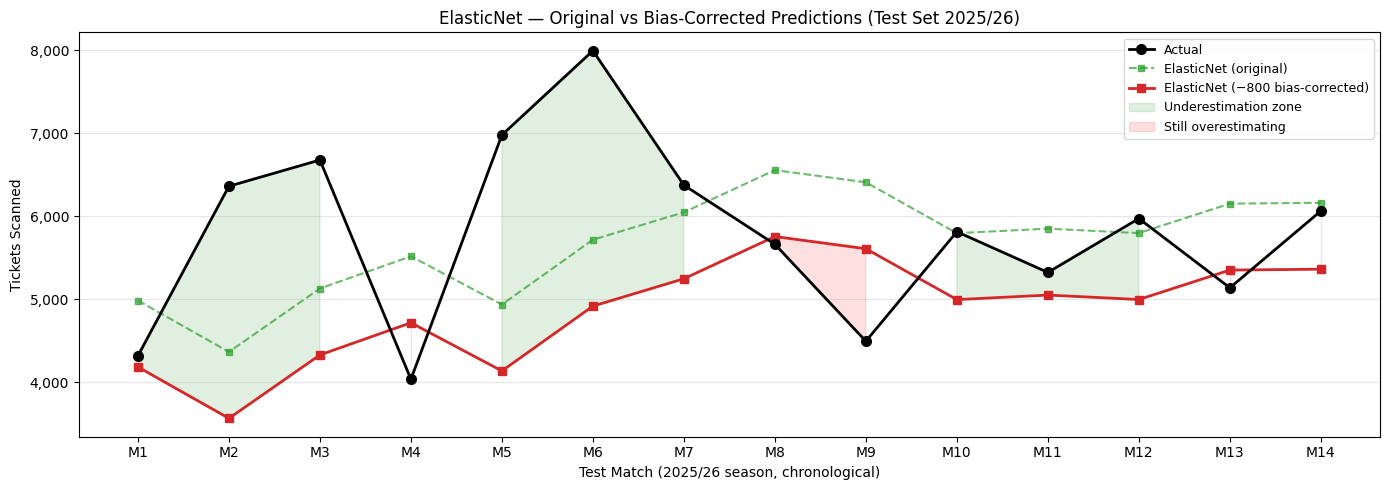

In [59]:
# --- Step 1: Quantify systematic overestimation on training data ---
train_pred_el = elastic.predict(X_red_train)
train_resid   = train_pred_el - y_red_train.values  # positive = overestimation

mean_bias = train_resid.mean()
std_resid  = train_resid.std()

print(f'Training residuals (predicted − actual):')
print(f'  Mean (systematic overestimation): {mean_bias:+.0f} tickets')
print(f'  Std:                              {std_resid:.0f} tickets')

# --- Step 2: Apply correction ---
# Subtract mean overestimation + safety buffer
SAFETY_BUFFER = 800  # tickets — adjust to taste
correction = mean_bias + SAFETY_BUFFER

y_original     = elastic.predict(X_red_test)
y_conservative = y_original - correction

print(f'\nCorrection applied: {correction:.0f} tickets')
print(f'  = mean bias ({mean_bias:.0f}) + safety buffer ({SAFETY_BUFFER})')

# --- Step 3: Residual summary ---
orig_mae  = np.abs(y_original     - y_red_test.values).mean()
cons_mae  = np.abs(y_conservative - y_red_test.values).mean()
orig_over = (y_original     > y_red_test.values).mean() * 100
cons_over = (y_conservative > y_red_test.values).mean() * 100

print(f'\n{"":30s} {"Original":>12} {"Conservative":>14}')
print(f'{"MAE (test)":30s} {orig_mae:>12.0f} {cons_mae:>14.0f}')
print(f'{"% matches overestimated":30s} {orig_over:>11.0f}% {cons_over:>13.0f}%')

# --- Step 4: Plot ---
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(y_red_test))
match_labels = [f'M{i+1}' for i in range(len(y_red_test))]

ax.plot(x, y_red_test.values, 'o-',  color='black',      lw=2,   ms=7,  label='Actual',              zorder=5)
ax.plot(x, y_original,        's--', color='#2ca02c',    lw=1.5, ms=5,  label='ElasticNet (original)',alpha=0.7)
ax.plot(x, y_conservative,    's-',  color='#d62728',    lw=2,   ms=6,  label=f'ElasticNet (−{correction:.0f} bias-corrected)')

ax.fill_between(x, y_conservative, y_red_test.values,
                where=(y_conservative < y_red_test.values),
                alpha=0.12, color='green', label='Underestimation zone')
ax.fill_between(x, y_conservative, y_red_test.values,
                where=(y_conservative >= y_red_test.values),
                alpha=0.12, color='red', label='Still overestimating')

ax.set_xticks(x)
ax.set_xticklabels(match_labels)
ax.set_xlabel('Test Match (2025/26 season, chronological)')
ax.set_ylabel('Tickets Scanned')
ax.set_title('ElasticNet — Original vs Bias-Corrected Predictions (Test Set 2025/26)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()